# Create dataset — Option B ghost cells (inflow + outflow)

Full pipeline for the **Option B** warmstart dataset:

1. Build `template_100m_inflow_outflow_gc.pkl` with two types of ghost cells:
   - **Inflow ghost cells** (msk==2): dual edges `[ghost → interior]`, prescribed WD from SFINCS
   - **Outflow ghost cells** (msk==3): dual edges `[interior → ghost]`, free-drainage (no BC)
2. Convert the warmstart SFINCS simulation to the warmstart dataset

Expected output:
```
database/datasets/train/template_100m_inflow_outflow_gc.pkl
database/datasets/train/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_inflow_outflow_gc.pkl
database/datasets/test/ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_inflow_outflow_gc.pkl
```

In [ ]:
import os, sys

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print('Repo root:', REPO_ROOT)

## Config

In [2]:
# --- Paths ---
SFINCS_DIR_TEMPLATE = (
    'database/raw_datasets_ahr/Simulations/'
    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon'
)
SFINCS_MAP_WARMSTART = (
    'database/raw_datasets_ahr/Simulations/'
    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart/sfincs_map.nc'
)
SFINCS_SRC_WARMSTART = (
    'database/raw_datasets_ahr/Simulations/'
    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart/sfincs.src'
)
SFINCS_DIS_WARMSTART = (
    'database/raw_datasets_ahr/Simulations/'
    'ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart/sfincs.dis'
)

TEMPLATE_PKL = 'database/datasets/train/template_100m_inflow_outflow_gc.pkl'
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_inflow_outflow_gc'
OUT_ROOT     = 'database/datasets'

MESH_RESOLUTIONS = [2000, 1000, 500]   # coarse gmsh levels [m], coarsest → finest

# WARNING: do NOT rebuild the template with the current code state — the Option B
# ghost-cell blocks in graph_creation.py / create_mesh_template_marg.py are commented
# out, so a rebuild would lose node_BC_outflow (the 87 outflow ghost cells) and their
# outward edge direction. The template on disk is correct.
FORCE_REBUILD_TEMPLATE = False
FORCE_REBUILD_DATASET  = True

## Step 1 — Build template

In [3]:
from database.create_mesh_template_marg import create_mesh_template_pkl

if FORCE_REBUILD_TEMPLATE and os.path.exists(TEMPLATE_PKL):
    os.remove(TEMPLATE_PKL)
    print('Deleted stale template:', TEMPLATE_PKL)

if os.path.exists(TEMPLATE_PKL):
    print('Template already exists:', TEMPLATE_PKL)
    print('Set FORCE_REBUILD_TEMPLATE = True to recreate.')
else:
    create_mesh_template_pkl(
        shapefile_path        = f'{SFINCS_DIR_TEMPLATE}/gis/region.geojson',
        dem_tif_path          = f'{SFINCS_DIR_TEMPLATE}/gis/dep.tif',
        output_pkl_path       = TEMPLATE_PKL,
        with_multiscale       = True,
        number_of_multiscales = 4,
        mesh_resolutions      = MESH_RESOLUTIONS,
        sfincs_map_nc         = f'{SFINCS_DIR_TEMPLATE}/sfincs_map.nc',
    )
    print('\nTemplate saved:', TEMPLATE_PKL)

Template already exists: database/datasets/train/template_100m_inflow_outflow_gc.pkl
Set FORCE_REBUILD_TEMPLATE = True to recreate.


## Step 2 — Inspect template (ghost cell counts)

In [4]:
import pickle, torch
import numpy as np

with open(TEMPLATE_PKL, 'rb') as f:
    template_data = pickle.load(f)[0]

# After mesh_list[::-1] in template creation, SFINCS (finest) is at meshes[0].
finest = template_data.mesh.meshes[0]
finest_offset = int(template_data.finest_offset) if hasattr(template_data, 'finest_offset') \
                else int(template_data.node_ptr[-2])

print(f'Total mesh faces (finest/SFINCS): {finest.face_x.shape[0]}')
print(f'Finest offset: {finest_offset}')

# Diagnostic: raw ghost cell counts from the mesh object
n_gc_in  = len(finest.ghost_cells_ids_inflow)  if hasattr(finest, 'ghost_cells_ids_inflow')  else 'N/A'
n_gc_out = len(finest.ghost_cells_ids_outflow) if hasattr(finest, 'ghost_cells_ids_outflow') else 'N/A'
print(f'\nGhost cells (mesh): inflow={n_gc_in}  outflow={n_gc_out}')
print(f'  → inflow ghost cells  [ghost → interior]  (inward edges, prescribed WD BC)')
print(f'  → outflow ghost cells [interior → ghost]  (outward edges — currently reverted to inward)')

n_in  = len(template_data.node_BC)
n_out = len(template_data.node_BC_outflow) if hasattr(template_data, 'node_BC_outflow') else 0
print(f'\nTemplate node_BC (inflow BC):   {n_in}  — prescribed BC in training')
print(f'  → IDs: {template_data.node_BC.tolist()[:10]}{"..." if n_in > 10 else ""}')
print(f'Template node_BC_outflow:        {n_out}  — NOT in BC, evolve freely')
if n_out > 0:
    print(f'  → IDs (first 10): {template_data.node_BC_outflow.tolist()[:10]}')
print(f'BC dummy shape: {tuple(template_data.BC.shape)}')

# Ghost cell positions
if n_in > 0:
    in_local = (template_data.node_BC.numpy() - finest_offset)
    in_xy    = finest.face_xy[in_local]
    print(f'\nInflow ghost positions  (x range): {in_xy[:,0].min():.0f} – {in_xy[:,0].max():.0f}')
else:
    print('\nNo inflow ghost cells — inflow BC will use face_bnd cells near sfincs.src.')

if n_out > 0:
    out_local = (template_data.node_BC_outflow.numpy() - finest_offset)
    out_xy    = finest.face_xy[out_local]
    print(f'Outflow ghost positions (x range): {out_xy[:,0].min():.0f} – {out_xy[:,0].max():.0f}')

# Sanity
if hasattr(template_data, 'node_BC_outflow'):
    overlap = set(template_data.node_BC.tolist()) & set(template_data.node_BC_outflow.tolist())
    print(f'\nOverlap inflow ∩ outflow ghost cells (should be 0): {len(overlap)}')

Total mesh faces (finest/SFINCS): 25081
Finest offset: 29802

Ghost cells (mesh): inflow=N/A  outflow=N/A
  → inflow ghost cells  [ghost → interior]  (inward edges, prescribed WD BC)
  → outflow ghost cells [interior → ghost]  (outward edges — currently reverted to inward)

Template node_BC (inflow BC):   1  — prescribed BC in training
  → IDs: [30078]
Template node_BC_outflow:        0  — NOT in BC, evolve freely
BC dummy shape: (1, 10, 2)

Inflow ghost positions  (x range): 345450 – 345450


### Step 2b — Visualise mesh scales + ghost cells

C:\Users\marrocol\AppData\Local\Temp\ipykernel_17584\2493503536.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


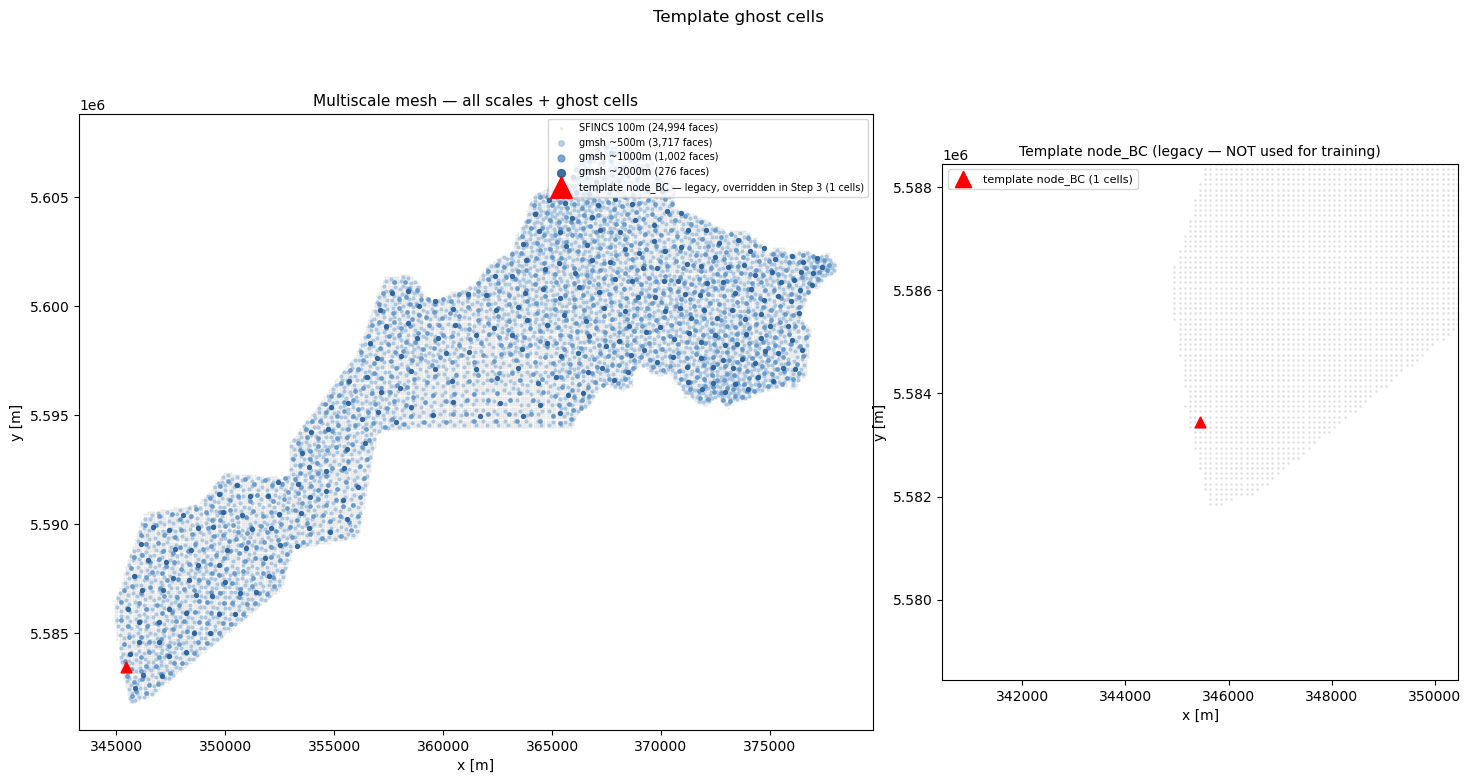

Template node_BC positions (overridden in Step 3):
[[ 345450. 5583450.]]


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# NOTE: this plots the TEMPLATE node_BC, which the dataset converter (Step 3)
# overrides with the 7 sfincs.src inflow nodes. There are NO msk==2 cells in this
# SFINCS model; any template node_BC entry is a legacy artifact (single boundary
# edge picked per coarse gmsh mesh, farthest from the domain centroid).
# The plot that matters for training is in Step 4 (final dataset BC).

meshes = template_data.mesh.meshes   # [0] = SFINCS (finest), [1..] = gmsh coarser

# Collect positions per scale (exclude ghost cells which are appended at the end)
scale_xy    = []
scale_names = []
for i, m in enumerate(meshes):
    xy   = np.asarray(m.face_xy)
    n_gc = len(m.ghost_cells_ids) if hasattr(m, 'ghost_cells_ids') else 0
    n_reg = xy.shape[0] - n_gc
    scale_xy.append(xy[:n_reg])
    res = ['SFINCS 100m', 'gmsh ~500m', 'gmsh ~1000m', 'gmsh ~2000m']
    scale_names.append(f'{res[i] if i < len(res) else f"scale {i}"} ({n_reg:,} faces)')

# Ghost cell positions (ghost cells are appended → face_xy[local_gc_id] works directly)
finest_xy = np.asarray(meshes[0].face_xy)

gc_in_xy, gc_out_xy = None, None
n_in  = len(template_data.node_BC)
n_out = len(template_data.node_BC_outflow) if hasattr(template_data, 'node_BC_outflow') else 0

if n_in > 0:
    in_loc   = template_data.node_BC.numpy() - finest_offset
    gc_in_xy = finest_xy[in_loc]

if n_out > 0:
    out_loc   = template_data.node_BC_outflow.numpy() - finest_offset
    gc_out_xy = finest_xy[out_loc]

# ---- Figure layout ----
has_zoom = gc_in_xy is not None or gc_out_xy is not None
n_zoom   = (gc_in_xy is not None) + (gc_out_xy is not None)
fig = plt.figure(figsize=(18, 8) if n_zoom else (10, 8))

if n_zoom:
    gs = gridspec.GridSpec(n_zoom, 2, figure=fig, width_ratios=[1.6, 1], hspace=0.35, wspace=0.08)
    ax_main = fig.add_subplot(gs[:, 0])
    zoom_axes = [fig.add_subplot(gs[i, 1]) for i in range(n_zoom)]
else:
    ax_main = fig.add_subplot(111)
    zoom_axes = []

# ---- Overview ----
colors = ['#d4d4d4', '#9dbfde', '#5d93c7', '#2a6099']
sizes  = [0.5,       4,         6,          8]
alphas = [0.4,       0.7,       0.8,        0.9]

for i, (xy, name) in enumerate(zip(scale_xy, scale_names)):
    ax_main.scatter(xy[:, 0], xy[:, 1],
                    s=sizes[min(i, len(sizes)-1)], c=colors[min(i, len(colors)-1)],
                    alpha=alphas[min(i, len(alphas)-1)], label=name, rasterized=True)

if gc_in_xy is not None:
    ax_main.scatter(gc_in_xy[:, 0], gc_in_xy[:, 1],
                    s=60, c='red', marker='^', zorder=7,
                    label=f'template node_BC — legacy, overridden in Step 3 ({n_in} cells)')
if gc_out_xy is not None:
    ax_main.scatter(gc_out_xy[:, 0], gc_out_xy[:, 1],
                    s=20, c='blue', marker='v', zorder=7,
                    label=f'Outflow GC — msk==3 ({n_out} cells)')

ax_main.set_aspect('equal')
ax_main.set_title('Multiscale mesh — all scales + ghost cells', fontsize=11)
ax_main.set_xlabel('x [m]'); ax_main.set_ylabel('y [m]')
ax_main.legend(fontsize=7, markerscale=2, loc='upper right')

# ---- Zoom panels ----
zoom_idx = 0
pad = 5000  # m padding around ghost cells

def _zoom(ax, gc_xy, bg_xy, color, marker, label):
    ax.scatter(bg_xy[:, 0], bg_xy[:, 1], s=1, c='#d4d4d4', alpha=0.5, rasterized=True)
    ax.scatter(gc_xy[:, 0], gc_xy[:, 1], s=60, c=color, marker=marker, zorder=6, label=label)
    xlo, xhi = gc_xy[:, 0].min() - pad, gc_xy[:, 0].max() + pad
    ylo, yhi = gc_xy[:, 1].min() - pad, gc_xy[:, 1].max() + pad
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    ax.set_aspect('equal'); ax.legend(fontsize=8, markerscale=1.5)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')

if gc_in_xy is not None and zoom_axes:
    ax_z = zoom_axes[zoom_idx]; zoom_idx += 1
    _zoom(ax_z, gc_in_xy, scale_xy[0], 'red', '^', f'template node_BC ({n_in} cells)')
    ax_z.set_title('Template node_BC (legacy — NOT used for training)', fontsize=10)

if gc_out_xy is not None and zoom_idx < len(zoom_axes):
    ax_z = zoom_axes[zoom_idx]
    _zoom(ax_z, gc_out_xy, scale_xy[0], 'blue', 'v', f'Outflow GC ({n_out} cells)')
    ax_z.set_title('Outflow ghost cells (msk==3)', fontsize=10)

plt.suptitle('Template ghost cells', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print(f'Template node_BC positions (overridden in Step 3):\n{gc_in_xy}' if gc_in_xy is not None
      else 'Template node_BC empty — Step 3 sets the inflow BC at the sfincs.src nodes.')
if gc_out_xy is not None:
    print(f'Outflow GC x-range: {gc_out_xy[:,0].min():.0f} – {gc_out_xy[:,0].max():.0f} m')
    print(f'Outflow GC y-range: {gc_out_xy[:,1].min():.0f} – {gc_out_xy[:,1].max():.0f} m')

## Step 3 — Build warmstart dataset

In [6]:
import copy
import xarray as xr
from scipy.interpolate import griddata

from database.convert_sfincs_to_pkl_marg import (
    load_single_data_object, get_target_points, build_output_data,
    parse_src_file, parse_dis_file,
)

# BC = discharge Q at the 7 sfincs.src injection points (type_BC=2), same as
# run_convert_warmstart_inflow_outflow_gc.py. The template node_BC is overridden here.
# (An earlier version prescribed ground-truth SFINCS WD at these cells (type_BC=1) —
#  that leaked the solution into the input and never exposed the model to the hydrograph.)

out_paths = {split: os.path.join(OUT_ROOT, split, f'{DATASET_NAME}.pkl') for split in ('train', 'test')}

if not FORCE_REBUILD_DATASET and all(os.path.exists(p) for p in out_paths.values()):
    print('Dataset already exists. Set FORCE_REBUILD_DATASET = True to recreate.')
else:
    print('Loading template...')
    template_data = load_single_data_object(TEMPLATE_PKL)
    target_points = get_target_points(template_data)
    num_targets   = target_points.shape[0]
    print(f'  Target mesh faces: {num_targets}')

    print('Opening SFINCS warmstart map...')
    ds  = xr.open_dataset(SFINCS_MAP_WARMSTART, decode_times=False)
    msk = ds['msk'].values
    zs  = ds['zs'].values
    zb  = ds['zb'].values

    if msk.ndim == 1:
        msk = msk.reshape(zs.shape[1], zs.shape[2])

    x = ds.coords['x'].values
    y = ds.coords['y'].values
    if x.ndim == 1 and y.ndim == 1:
        if len(x) == msk.shape[1] and len(y) == msk.shape[0]:
            x, y = np.meshgrid(x, y, indexing='xy')
        elif x.shape[0] == msk.size:
            x = x.reshape(msk.shape)
            y = y.reshape(msk.shape)

    active        = msk > 0
    source_points = np.column_stack([x[active], y[active]])
    time_var      = ds.coords.get('time', ds.coords.get('t', None))
    map_times_s   = (time_var.values.astype(np.float64) if time_var is not None
                     else np.arange(zs.shape[0]) * 3600.0)
    time_steps    = zs.shape[0]
    print(f'  Active SFINCS cells: {source_points.shape[0]}  |  time steps: {time_steps}')

    # WD for full mesh
    print('Interpolating WD...')
    zs_active = zs[:, active]
    zb_active = zb[active]
    WD_active  = np.maximum(np.where(np.isnan(zs_active), zb_active, zs_active) - zb_active, 0.0).astype(np.float32)
    WD = np.zeros((num_targets, time_steps), dtype=np.float32)
    for t in range(time_steps):
        iv = griddata(source_points, WD_active[t], target_points, method='linear')
        WD[:, t] = np.nan_to_num(iv, nan=0.0)
    del WD_active, zs_active
    print(f'  WD done: {WD.shape}  peak={WD.max():.3f} m')

    # Velocities
    ds_raw = xr.open_dataset(SFINCS_MAP_WARMSTART, decode_times=False, mask_and_scale=False)
    VX = np.zeros((num_targets, time_steps), dtype=np.float32)
    VY = np.zeros((num_targets, time_steps), dtype=np.float32)
    for var, arr_out in [('u', VX), ('v', VY)]:
        if var in ds_raw.data_vars:
            print(f'Interpolating {var}...')
            raw = ds_raw[var].values.astype(np.float32)
            fv  = ds_raw[var].attrs.get('_FillValue', None)
            if fv is not None:
                raw[raw == float(fv)] = np.nan
            act = raw[:, active]
            del raw
            for t in range(time_steps):
                ok = np.isfinite(act[t])
                if ok.sum() > 3:
                    iv = griddata(source_points[ok], act[t][ok], target_points, method='linear')
                    arr_out[:, t] = np.nan_to_num(iv, nan=0.0)
            del act
    ds_raw.close()

    del zs, zb
    ds.close()

    # --- BC: discharge Q at the sfincs.src points ---
    print('\nBuilding discharge BC from sfincs.src / sfincs.dis...')
    src_xy = parse_src_file(SFINCS_SRC_WARMSTART)
    dis_times_s, discharge = parse_dis_file(SFINCS_DIS_WARMSTART)
    print(f'  {len(src_xy)} source points')

    # build_output_data maps src -> face_bnd cells, interpolates Q to map times,
    # sets type_BC=2 and edge_BC_length
    data_out = build_output_data(template_data, WD=WD, VX=VX, VY=VY,
                                 map_times_s=map_times_s,
                                 src_xy=src_xy, dis_times_s=dis_times_s, discharge=discharge)

    # Carry over outflow ghost cell IDs (not in node_BC — they evolve freely)
    if hasattr(template_data, 'node_BC_outflow'):
        data_out.node_BC_outflow = template_data.node_BC_outflow

    print(f'\n=== BC summary ===')
    print(f'  node_BC shape : {tuple(data_out.node_BC.shape)}')
    print(f'  node_BC       : {data_out.node_BC.tolist()}')
    print(f'  BC shape      : {tuple(data_out.BC.shape)}')
    print(f'  type_BC       : {data_out.type_BC.item()} (2 = discharge -> VX slot)')
    print(f'  Q peak        : {data_out.BC[:, :, 1].max().item():.1f} m^3/s')
    if hasattr(data_out, 'node_BC_outflow'):
        print(f'  outflow ghost cells (free, not in BC): {len(data_out.node_BC_outflow)}')

    for split in ('train', 'test'):
        out_dir = os.path.join(OUT_ROOT, split)
        os.makedirs(out_dir, exist_ok=True)
        out_path = out_paths[split]
        with open(out_path, 'wb') as f:
            pickle.dump([copy.deepcopy(data_out)], f)
        print(f'  Saved: {out_path}')

    print(f'\nDone.  WD={tuple(data_out.WD.shape)}')

Loading template...
  Target mesh faces: 30079
Opening SFINCS warmstart map...


  Active SFINCS cells: 24994  |  time steps: 119
Interpolating WD...


  WD done: (30079, 119)  peak=10.723 m
Interpolating u...


Interpolating v...



Building discharge BC from sfincs.src / sfincs.dis...
  7 source points
  Mapped 7 source points to BOUNDARY mesh nodes: [12555  7287    15   368  5453  3676  6427]

=== BC summary ===
  node_BC shape : (7,)
  node_BC       : [12555, 7287, 15, 368, 5453, 3676, 6427]
  BC shape      : (7, 119, 2)
  type_BC       : 2 (2 = discharge -> VX slot)
  Q peak        : 450.0 m^3/s
  Saved: database/datasets\train\ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_inflow_outflow_gc.pkl


  Saved: database/datasets\test\ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart_inflow_outflow_gc.pkl

Done.  WD=(30079, 119)


## Step 4 — Quick sanity check

WD shape : (30079, 119)
node_BC  : [12555, 7287, 15, 368, 5453, 3676, 6427]
BC shape : (7, 119, 2)
type_BC  : 2  (2 = discharge -> VX slot)
Q peak (channel 1): 450.0 m^3/s
BC NaNs  : 0

WD peak in full mesh  : 10.723342895507812 m
WD min in full mesh   : -1.759838002862897e-16 m (should be 0)


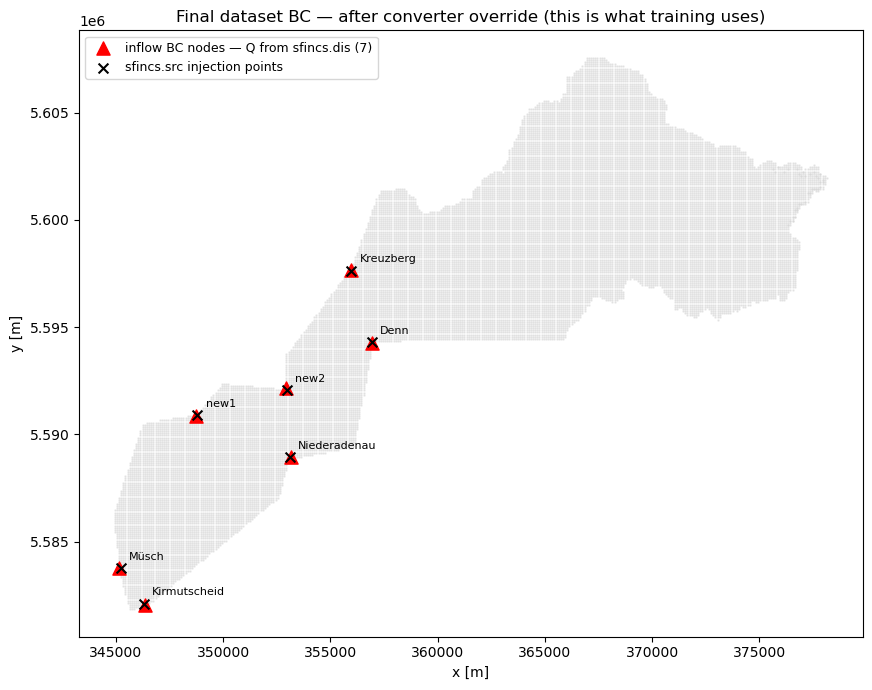

In [7]:
with open(out_paths['train'], 'rb') as f:
    d = pickle.load(f)[0]

print('WD shape :', tuple(d.WD.shape))
print('node_BC  :', d.node_BC.tolist())
print('BC shape :', tuple(d.BC.shape))
print('type_BC  :', d.type_BC.item(), ' (2 = discharge -> VX slot)')
print('Q peak (channel 1):', d.BC[:, :, 1].max().item(), 'm^3/s')
print('BC NaNs  :', int(torch.isnan(d.BC).sum()))
print()
print('WD peak in full mesh  :', d.WD.max().item(), 'm')
print('WD min in full mesh   :', d.WD.min().item(), 'm (should be 0)')

# Check outflow ghost cells are NOT in node_BC
if hasattr(d, 'node_BC_outflow'):
    overlap = set(d.node_BC.tolist()) & set(d.node_BC_outflow.tolist())
    print(f'\nOutflow ghost cells in node_BC (should be 0): {len(overlap)}')
    print(f'node_BC_outflow: {d.node_BC_outflow.tolist()[:5]} ... ({len(d.node_BC_outflow)} cells)')

# --- Map of the FINAL BC configuration (what the model actually sees) ---
src_names = ['Kreuzberg', 'Denn', 'Kirmutscheid', 'Müsch', 'new1', 'Niederadenau', 'new2']
src_xy = parse_src_file(SFINCS_SRC_WARMSTART)

finest = d.mesh.meshes[0]                     # SFINCS scale, offset 0
xy = np.asarray(finest.face_xy)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(xy[:, 0], xy[:, 1], s=0.5, c='#d4d4d4', alpha=0.5, rasterized=True)

in_xy = xy[d.node_BC.numpy()]
ax.scatter(in_xy[:, 0], in_xy[:, 1], s=90, c='red', marker='^', zorder=6,
           label=f'inflow BC nodes — Q from sfincs.dis ({len(d.node_BC)})')
ax.scatter(src_xy[:, 0], src_xy[:, 1], s=50, c='k', marker='x', zorder=7,
           label='sfincs.src injection points')
for i, (sx, sy) in enumerate(src_xy):
    name = src_names[i] if i < len(src_names) else f'src {i}'
    ax.annotate(name, (sx, sy), textcoords='offset points', xytext=(6, 6), fontsize=8)

if hasattr(d, 'node_BC_outflow'):
    out_xy = xy[d.node_BC_outflow.numpy()]
    ax.scatter(out_xy[:, 0], out_xy[:, 1], s=25, c='blue', marker='v', zorder=5,
               label=f'outflow ghost cells — free, no BC ({len(d.node_BC_outflow)})')

ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('Final dataset BC — after converter override (this is what training uses)')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()